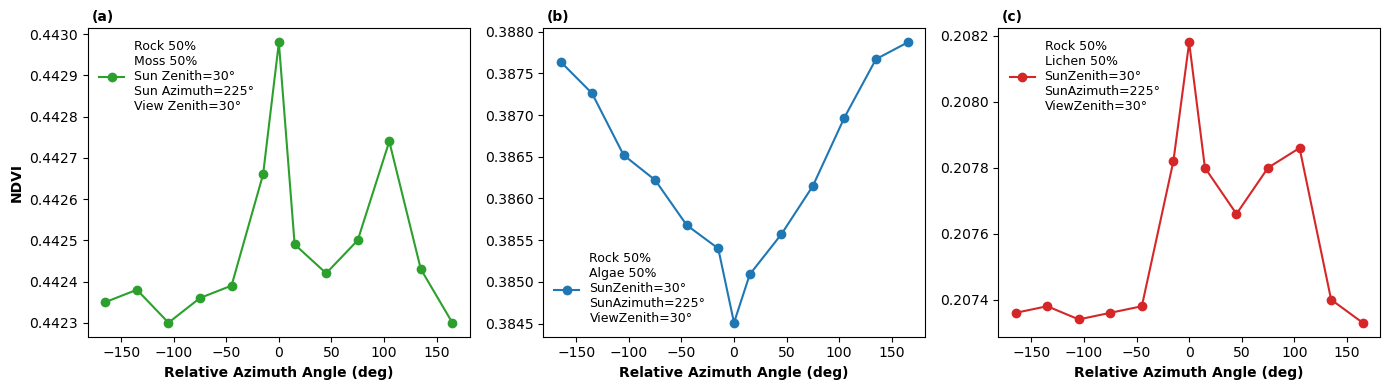

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ========= Fixed angles =========
SUN_ZEN = 30   # deg
SUN_AZ  = 225  # deg
VIEW_ZEN = 30  # deg

# ========= View azimuth values =========
azimuth = np.array([0, 30, 60, 90, 120, 150, 180, 210, 225, 240, 270, 300, 330])

# ========= Compute Relative Azimuth Angle (-180 to 180°) =========
rel_azi = (azimuth - SUN_AZ + 180) % 360 - 180

# ========= Sort values for smooth plotting =========
sort_idx = np.argsort(rel_azi)
rel_azi_sorted = rel_azi[sort_idx]

# ========= NDVI for each composition =========
ndvi_moss50 = np.array([0.44243, 0.44230, 0.44235, 0.44238, 0.44230, 
                        0.44236, 0.44239, 0.44266, 0.44298, 0.44249, 
                        0.44242, 0.44250, 0.44274])[sort_idx]

ndvi_algae50 = np.array([0.38767,0.38787,0.38764,0.38726,0.38652,
                         0.38622,0.38568,0.38540,0.38451,0.38509,
                         0.38557,0.38615,0.38697])[sort_idx]

ndvi_lichen50 = np.array([0.20740,0.20733,0.20736,0.20738,0.20734,
                          0.20736,0.20738,0.20782,0.20818,0.20780,
                          0.20766,0.20780,0.20786])[sort_idx]

# ========= Plotting (1×3 subplots) =========
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=False)

# ---- Subplot 1: Moss 50% ----
axes[0].plot(rel_azi_sorted, ndvi_moss50, marker="o", color="tab:green")
axes[0].text(0.01, 1.06, "(a)", transform=axes[0].transAxes,
             fontsize=10, fontweight="bold", va="top")
axes[0].set_xlabel("Relative Azimuth Angle (deg)", fontweight="bold")
axes[0].set_ylabel("NDVI", fontweight="bold")
axes[0].legend(
    [f"Rock 50%\nMoss 50%\nSun Zenith={SUN_ZEN}° \nSun Azimuth={SUN_AZ}°\nView Zenith={VIEW_ZEN}°"],
    loc="upper left", fontsize=9
).get_frame().set_visible(False)

# ---- Subplot 2: Algae 50% ----
axes[1].plot(rel_azi_sorted, ndvi_algae50, marker="o", color="tab:blue")
axes[1].text(0.01, 1.06, "(b)", transform=axes[1].transAxes,
             fontsize=10, fontweight="bold", va="top")
axes[1].set_xlabel("Relative Azimuth Angle (deg)", fontweight="bold")
axes[1].legend(
    [f"Rock 50%\nAlgae 50%\nSunZenith={SUN_ZEN}°\nSunAzimuth={SUN_AZ}°\nViewZenith={VIEW_ZEN}°"],
    loc="lower left", fontsize=9
).get_frame().set_visible(False)

# ---- Subplot 3: Lichen 50% ----
axes[2].plot(rel_azi_sorted, ndvi_lichen50, marker="o", color="tab:red")
axes[2].text(0.01, 1.06, "(c)", transform=axes[2].transAxes,
             fontsize=10, fontweight="bold", va="top")
axes[2].set_xlabel("Relative Azimuth Angle (deg)", fontweight="bold")
axes[2].legend(
    [f"Rock 50%\nLichen 50%\nSunZenith={SUN_ZEN}°\nSunAzimuth={SUN_AZ}°\nViewZenith={VIEW_ZEN}°"],
    loc="upper left", fontsize=9
).get_frame().set_visible(False)

plt.tight_layout()
#plt.savefig(r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Dart_Azimuth_Angle_Effects.png", dpi=300, bbox_inches='tight')

plt.show()

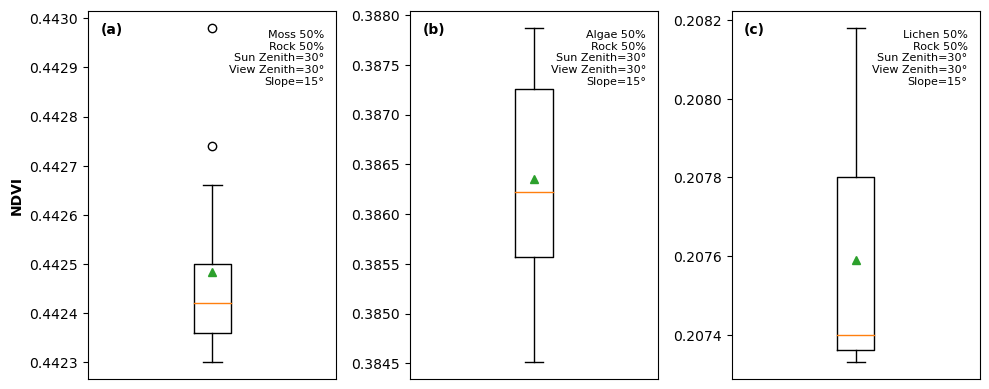

In [2]:
# ========= NDVI boxplots (1×3 subplots) =========
fig2, axes2 = plt.subplots(1, 3, figsize=(10, 4), sharey=False)

info_text = (
    f"Rock 50%\n"
    f"Sun Zenith={SUN_ZEN}°\n"
    f"View Zenith={VIEW_ZEN}°\n"
    f"Slope=15°"
)

# ---- Box 1: Moss 50% ----
axes2[0].boxplot(ndvi_moss50, vert=True, showmeans=True)
axes2[0].text(0.05, 0.93, "(a)", transform=axes2[0].transAxes,
              fontsize=10, fontweight="bold", va="bottom")

# info block (top right inside the box)
axes2[0].text(
    0.95, 0.95, f"Moss 50%\n{info_text}",
    transform=axes2[0].transAxes,
    fontsize=8, va="top", ha="right"
)

axes2[0].set_ylabel("NDVI", fontweight="bold")
axes2[0].set_xticks([])

# ---- Box 2: Algae 50% ----
axes2[1].boxplot(ndvi_algae50, vert=True, showmeans=True)
axes2[1].text(0.05, 0.93, "(b)", transform=axes2[1].transAxes,
              fontsize=10, fontweight="bold", va="bottom")

axes2[1].text(
    0.95, 0.95, f"Algae 50%\n{info_text}",
    transform=axes2[1].transAxes,
    fontsize=8, va="top", ha="right"
)
axes2[1].set_xticks([])

# ---- Box 3: Lichen 50% ----
axes2[2].boxplot(ndvi_lichen50, vert=True, showmeans=True)
axes2[2].text(0.05, 0.93, "(c)", transform=axes2[2].transAxes,
              fontsize=10, fontweight="bold", va="bottom")

axes2[2].text(
    0.95, 0.95, f"Lichen 50%\n{info_text}",
    transform=axes2[2].transAxes,
    fontsize=8, va="top", ha="right"
)
axes2[2].set_xticks([])

plt.tight_layout()

plt.savefig(
    r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Dart_Azimuth_Angle_Effects_Boxplot.png",
    dpi=300, bbox_inches="tight"
)

plt.show()

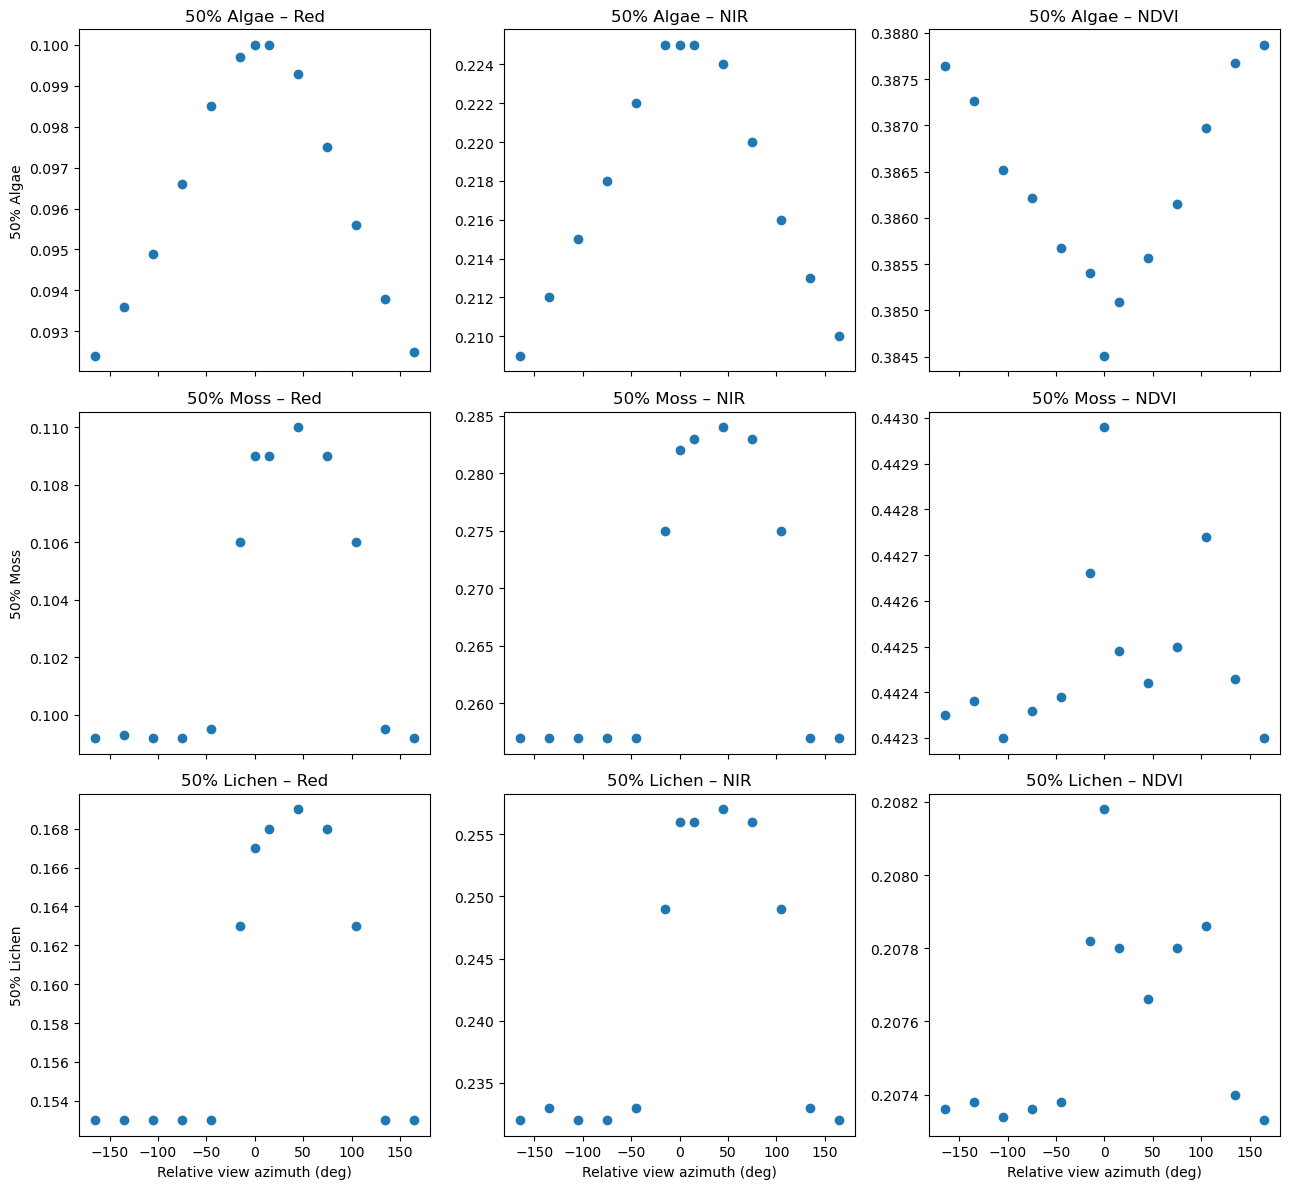

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Basic geometry
# ------------------------
SUN_AZ = 225
view_azimuth = np.array([0, 30, 60, 90, 120, 150, 180, 210, 225, 240, 270, 300, 330])

# Relative azimuth: 0–180
diff = (view_azimuth - SUN_AZ + 180) % 360 - 180
rel_azi = (diff)

# ------------------------
# Data arrays
# ------------------------

# ----------- 50% Algae -----------
red_algae = np.array([9.38E-02, 9.25E-02, 9.24E-02, 9.36E-02, 9.49E-02,
                      9.66E-02, 9.85E-02, 9.97E-02, 1.00E-01, 1.00E-01,
                      9.93E-02, 9.75E-02, 9.56E-02])

nir_algae = np.array([2.13E-01, 2.10E-01, 2.09E-01, 2.12E-01, 2.15E-01,
                      2.18E-01, 2.22E-01, 2.25E-01, 2.25E-01, 2.25E-01,
                      2.24E-01, 2.20E-01, 2.16E-01])

ndvi_algae = np.array([0.38767, 0.38787, 0.38764, 0.38726, 0.38652,
                       0.38622, 0.38568, 0.38540, 0.38451, 0.38509,
                       0.38557, 0.38615, 0.38697])


# ----------- 50% Moss -----------
red_moss = np.array([9.95E-02, 9.92E-02, 9.92E-02, 9.93E-02, 9.92E-02,
                     9.92E-02, 9.95E-02, 1.06E-01, 1.09E-01, 1.09E-01,
                     1.10E-01, 1.09E-01, 1.06E-01])

nir_moss = np.array([2.57E-01, 2.57E-01, 2.57E-01, 2.57E-01, 2.57E-01,
                     2.57E-01, 2.57E-01, 2.75E-01, 2.82E-01, 2.83E-01,
                     2.84E-01, 2.83E-01, 2.75E-01])

ndvi_moss = np.array([0.44243, 0.44230, 0.44235, 0.44238, 0.44230,
                      0.44236, 0.44239, 0.44266, 0.44298, 0.44249,
                      0.44242, 0.44250, 0.44274])


# ----------- 50% Lichen -----------
red_lichen = np.array([1.53E-01, 1.53E-01, 1.53E-01, 1.53E-01, 1.53E-01,
                       1.53E-01, 1.53E-01, 1.63E-01, 1.67E-01, 1.68E-01,
                       1.69E-01, 1.68E-01, 1.63E-01])

nir_lichen = np.array([2.33E-01, 2.32E-01, 2.32E-01, 2.33E-01, 2.32E-01,
                       2.32E-01, 2.33E-01, 2.49E-01, 2.56E-01, 2.56E-01,
                       2.57E-01, 2.56E-01, 2.49E-01])

ndvi_lichen = np.array([0.20740, 0.20733, 0.20736, 0.20738, 0.20734,
                        0.20736, 0.20738, 0.20782, 0.20818, 0.20780,
                        0.20766, 0.20780, 0.20786])

# ------------------------
# Plotting 3×3 grid
# ------------------------

materials = ["50% Algae", "50% Moss", "50% Lichen"]
reds = [red_algae, red_moss, red_lichen]
nirs = [nir_algae, nir_moss, nir_lichen]
ndvis = [ndvi_algae, ndvi_moss, ndvi_lichen]

fig, axs = plt.subplots(3, 3, figsize=(13, 12), sharex=True)

for i in range(3):
    # RED
    axs[i, 0].scatter(rel_azi, reds[i], marker='o')
    axs[i, 0].set_title(f"{materials[i]} – Red")
    axs[i, 0].set_ylabel(materials[i])

    # NIR
    axs[i, 1].scatter(rel_azi, nirs[i], marker='o')
    axs[i, 1].set_title(f"{materials[i]} – NIR")

    # NDVI
    axs[i, 2].scatter(rel_azi, ndvis[i], marker='o')
    axs[i, 2].set_title(f"{materials[i]} – NDVI")

for j in range(3):
    axs[2, j].set_xlabel("Relative view azimuth (deg)")

plt.tight_layout()
plt.show()